In [67]:
import sys
from pathlib import Path

project_root = Path.cwd().parents[2]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [68]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [69]:
import numpy as np
import tsplib95

from clonalg.antibody.permutation_antibody import (
    PermutationAntibody,
    PermutationAntibodyBuilder,
)
from clonalg.model.clonalg_optimization import OptimizationClonalg
from clonalg.problems.problem import Rastrigin
from clonalg.visualization.visualization import plot_3d_surface, plot_contour_and_paths

In [70]:
def gap(found: float, optimal: int) -> float:
    return (found - optimal) / optimal * 100

In [71]:
def load_solutions(filepath: str) -> dict[str, int]:
    solutions = {}
    for line in Path(filepath).read_text().splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue

        name, _, rest = line.partition(":")
        solutions[name.strip().lower()] = int(rest.strip())
    return solutions


solutions = load_solutions("./data/solutions")

In [72]:
import matplotlib.pyplot as plt
import numpy as np


def plot_tsp(coords: np.ndarray, tour: np.ndarray, title: str = "TSP solution"):
    # coords: array (n, 2) with x, y positions
    # tour: array of city indices (without depot)
    full_tour = np.concatenate(([0], tour, [0]))  # close the loop

    fig, ax = plt.subplots(figsize=(8, 6))

    # draw edges
    for i in range(len(full_tour) - 1):
        a, b = full_tour[i], full_tour[i + 1]
        ax.plot(
            [coords[a, 0], coords[b, 0]],
            [coords[a, 1], coords[b, 1]],
            "b-",
            linewidth=0.8,
            alpha=0.6,
        )

    # draw cities
    ax.scatter(coords[:, 0], coords[:, 1], c="red", s=20, zorder=3)

    # label cities
    for i, (x, y) in enumerate(coords):
        ax.annotate(str(i), (x, y), fontsize=7, ha="right")

    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    plt.show()

In [73]:
def tour_cost(tour: np.ndarray, problem: tsplib95.models.StandardProblem) -> int:
    n = len(tour)
    return sum(
        problem.get_weight(int(tour[i]), int(tour[(i + 1) % n])) for i in range(n)
    )

In [74]:
def tour_edges(genes: np.ndarray) -> set[frozenset[int]]:
    tour = np.concatenate(([1], genes))
    n = len(tour)
    return {frozenset((int(tour[i]), int(tour[(i + 1) % n]))) for i in range(n)}


def edge_distance(a: np.ndarray, b: np.ndarray) -> int:
    "Number of edges present in tour `a` but not in tour `b` (TSP-aware, symmetric, rotation/reflection invariant)."
    return len(tour_edges(a) - tour_edges(b))

In [ ]:
PROBLEM_NAME = "bayg29"

problem = tsplib95.load(f"./data/{PROBLEM_NAME}.tsp")
problem.dimension  # cities are labeled from 1 to N

n_cities = problem.dimension
bounds = [(2, problem.dimension)] * (n_cities - 1)

29

In [ ]:
def factory() -> PermutationAntibody:
    genes = np.random.permutation(np.arange(2, n_cities + 1))
    return (
        PermutationAntibodyBuilder()
        .with_genes(genes)
        .with_cost_fn(lambda g: tour_cost(np.concatenate(([1], g)), problem))
        .with_distance_fn(edge_distance)
        .build()
    )

In [96]:
def run_clonalg(
    problem_name: str,
    problem,
    config: dict,
    solutions: dict,
    n_cities: int,
    n_generations: int = 10,
) -> None:
    clonalg = OptimizationClonalg(
        **{
            **config.get(problem_name, config["default"]),
            "n_generations": n_generations,
        }
    )

    memory = clonalg.run()
    memory.sort(key=lambda ab: ab.affinity(None), reverse=True)

    best = memory[0]
    best_tour = np.concatenate(([1], best.genes))

    print(f"Tour cost = {tour_cost(best_tour, problem)}")
    print(f"Best tour cost = {solutions[problem_name]}")
    print(f"Affinity = {best.affinity(None):.6f}")
    print(
        f"Gap from optimal: {gap(tour_cost(best_tour, problem), solutions[problem_name]):.2f}%"
    )

    coords_dict = problem.node_coords or problem.display_data

    coords = np.array([coords_dict[i + 1] for i in range(n_cities)])
    plot_tsp(
        coords,
        best.genes - 1,
        title=(
            f"Problem: {problem_name} | Tour cost: {tour_cost(best_tour, problem)} "
            f"(optimal: {solutions[problem_name]})\n"
            f"Generations: {n_generations}"
        ),
    )

In [119]:
config = {
    "pr124": {
        "population_size": 80,
        "clone_factor": 0.15,
        "rho": 5.0,
        "suppression_threshold": 4.0,
        "antibody_factory": factory,
        "n_generations": 1000,
    },
    "berlin52": {
        "population_size": 40,
        "clone_factor": 0.3,
        "rho": 3.0,
        "suppression_threshold": 2.0,
        "antibody_factory": factory,
        "n_generations": 1000,
    },
    "bays29": {
        "population_size": 20,
        "clone_factor": 0.2,
        "rho": 3.0,
        "suppression_threshold": 2.0,
        "antibody_factory": factory,
        "n_generations": 1000,
    },
    "bayg29": {
        "population_size": 20,
        "clone_factor": 0.2,
        "rho": 3.0,
        "suppression_threshold": 2.0,
        "antibody_factory": factory,
        "n_generations": 1000,
    },
    "default": {
        "population_size": 80,
        "clone_factor": 0.15,
        "rho": 5.0,
        "suppression_threshold": 4.0,
        "antibody_factory": factory,
        "n_generations": 1000,
    },
}

100%|██████████| 10/10 [00:00<00:00, 32.05it/s]

Tour cost = 3122
Best tour cost = 1610
Affinity = 0.000320
Gap from optimal: 93.91%


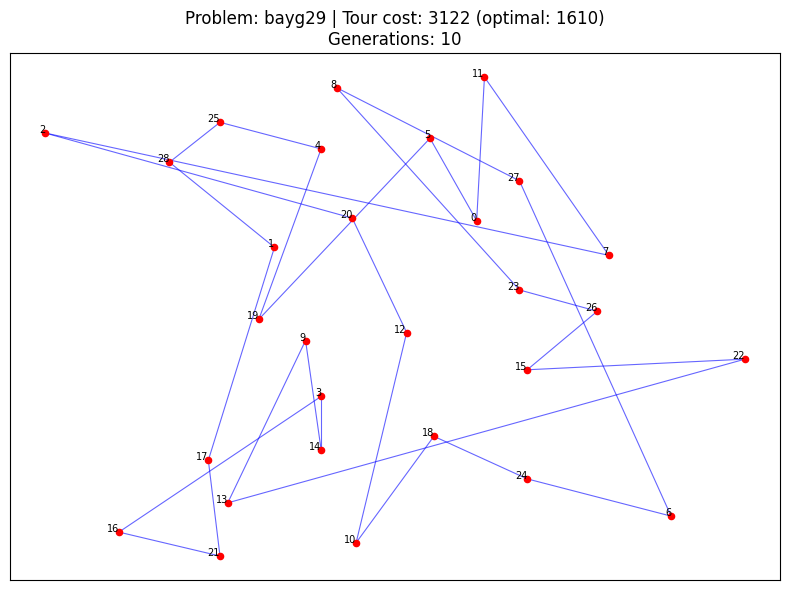

In [79]:
run_clonalg(PROBLEM_NAME, problem, config, solutions, n_cities, n_generations=10)

100%|██████████| 50/50 [00:01<00:00, 30.83it/s]

Tour cost = 2267
Best tour cost = 1610
Affinity = 0.000441
Gap from optimal: 40.81%


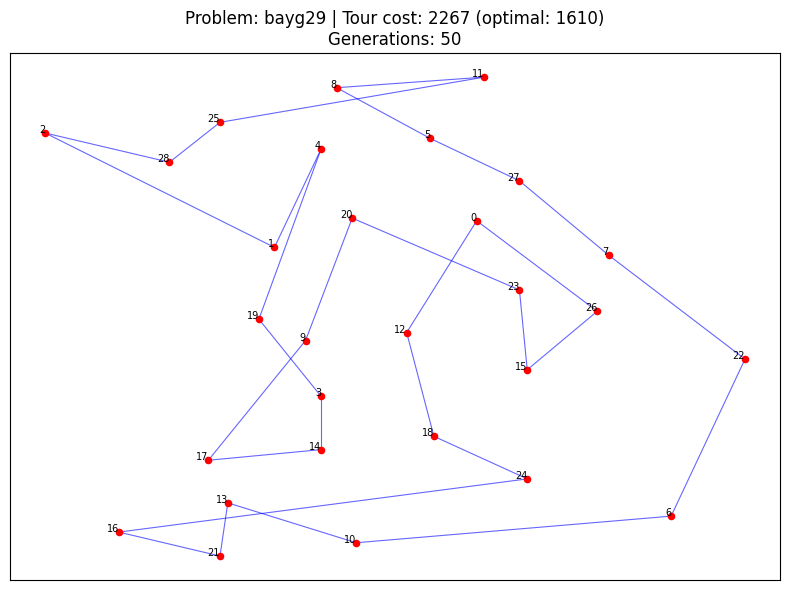

In [80]:
run_clonalg(PROBLEM_NAME, problem, config, solutions, n_cities, n_generations=50)

100%|██████████| 500/500 [00:15<00:00, 32.19it/s]

Tour cost = 1643
Best tour cost = 1610
Affinity = 0.000608
Gap from optimal: 2.05%


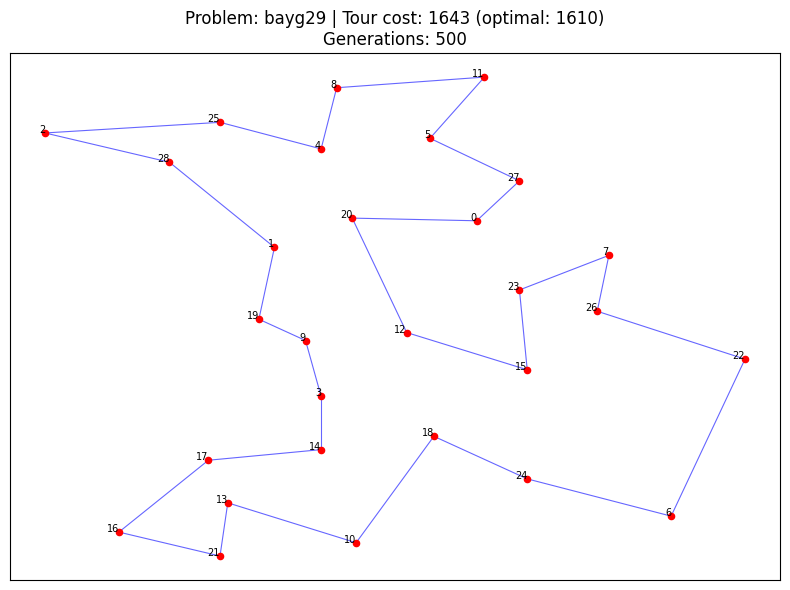

In [81]:
run_clonalg(PROBLEM_NAME, problem, config, solutions, n_cities, n_generations=500)

100%|██████████| 2000/2000 [01:13<00:00, 27.15it/s]


Tour cost = 1622
Best tour cost = 1610
Affinity = 0.000616
Gap from optimal: 0.75%


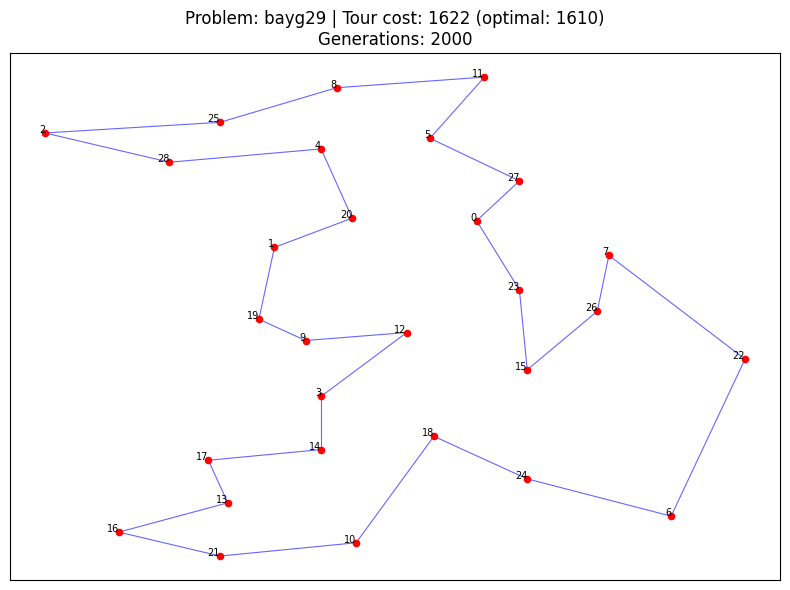

In [82]:
run_clonalg(PROBLEM_NAME, problem, config, solutions, n_cities, n_generations=2000)

--

In [110]:
PROBLEM_NAME = "ch130"
problem = tsplib95.load(f"./data/{PROBLEM_NAME}.tsp")

n_cities = problem.dimension
bounds = [(2, problem.dimension)] * (n_cities - 1)
problem.dimension  # cities are labeled from 1 to N

130

100%|██████████| 10/10 [00:01<00:00,  6.91it/s]


Tour cost = 37418
Best tour cost = 6110
Affinity = 0.000027
Gap from optimal: 512.41%


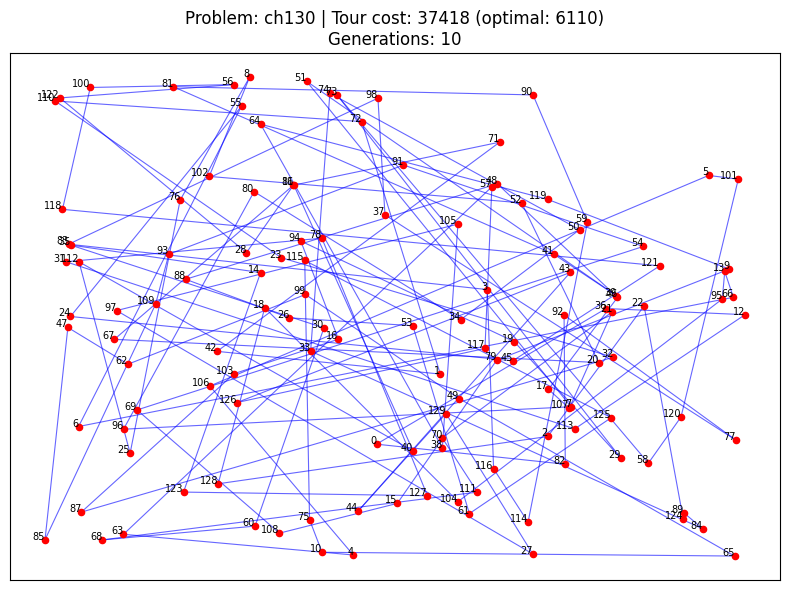

In [111]:
run_clonalg(PROBLEM_NAME, problem, config, solutions, n_cities, n_generations=10)

100%|██████████| 100/100 [00:14<00:00,  6.84it/s]


Tour cost = 31692
Best tour cost = 6110
Affinity = 0.000032
Gap from optimal: 418.69%


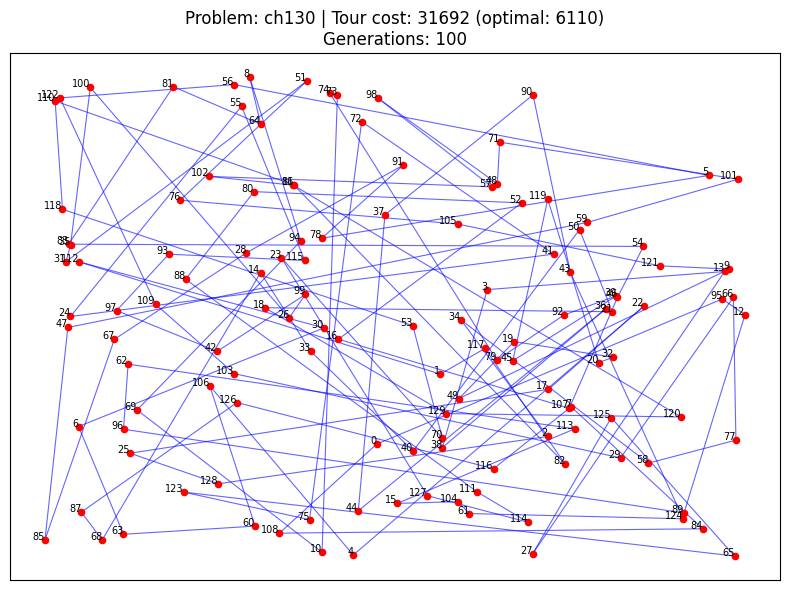

In [112]:
run_clonalg(PROBLEM_NAME, problem, config, solutions, n_cities, n_generations=100)

100%|██████████| 1000/1000 [02:39<00:00,  6.29it/s]


Tour cost = 24272
Best tour cost = 6110
Affinity = 0.000041
Gap from optimal: 297.25%


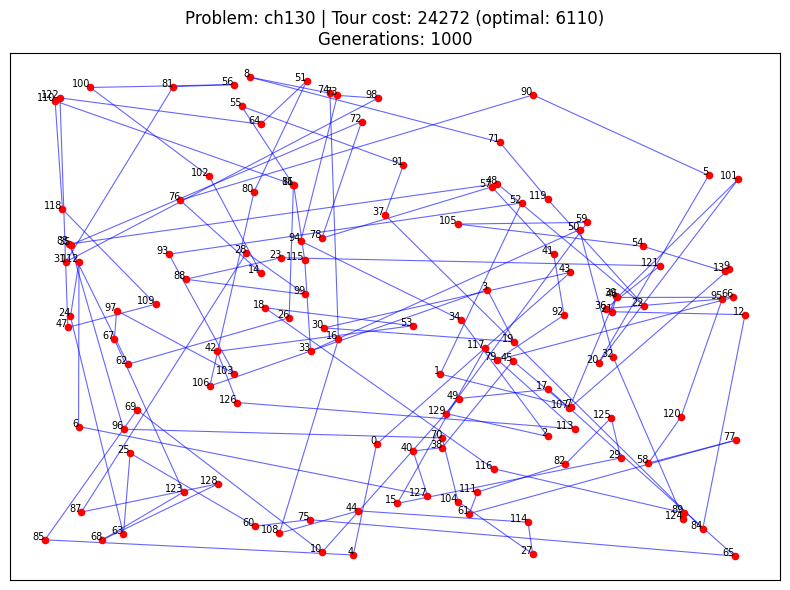

In [114]:
run_clonalg(PROBLEM_NAME, problem, config, solutions, n_cities, n_generations=1000)

--

In [120]:
PROBLEM_NAME = "gr96"
problem = tsplib95.load(f"./data/{PROBLEM_NAME}.tsp")

n_cities = problem.dimension
bounds = [(2, problem.dimension)] * (n_cities - 1)
problem.dimension  # cities are labeled from 1 to N

96

100%|██████████| 10/10 [00:10<00:00,  1.03s/it]


Tour cost = 273379
Best tour cost = 55209
Affinity = 0.000004
Gap from optimal: 395.17%


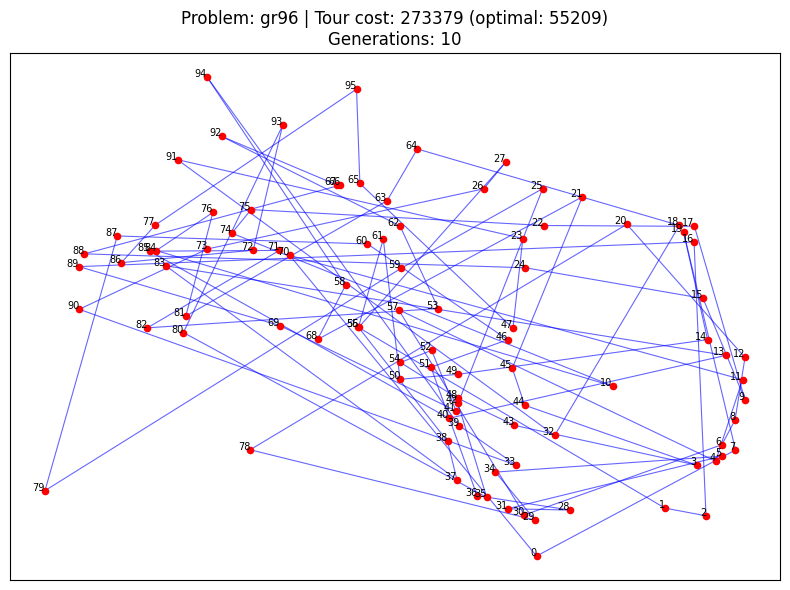

In [121]:
run_clonalg(PROBLEM_NAME, problem, config, solutions, n_cities, n_generations=10)

100%|██████████| 1000/1000 [17:17<00:00,  1.04s/it]


Tour cost = 60671
Best tour cost = 55209
Affinity = 0.000016
Gap from optimal: 9.89%


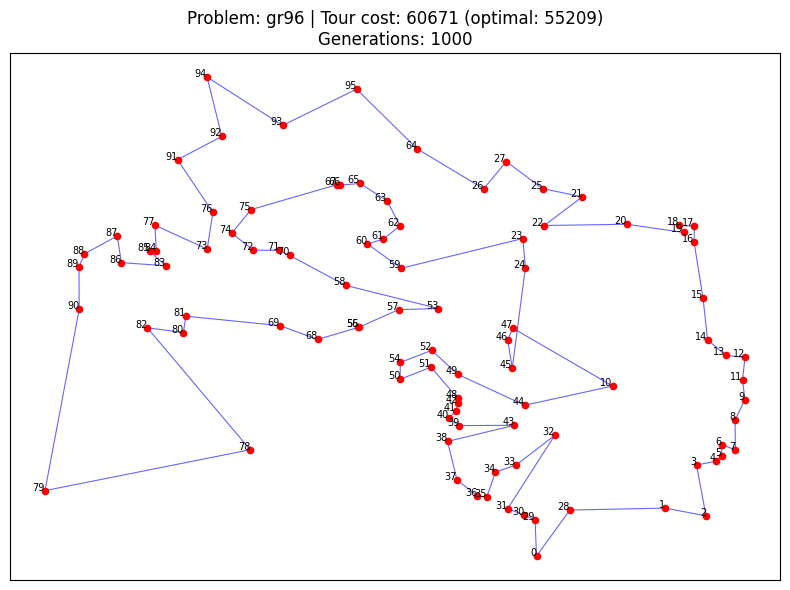

In [122]:
run_clonalg(PROBLEM_NAME, problem, config, solutions, n_cities, n_generations=1000)